# Final Configurations (Unified Views and Mass-Only)
* **Image Preprocessing**:
  * CLAHE + Median Blur
* **Image Views**:
  * Unified (CC + MLO)
* **Lesions**:
  * Mass-Only

### Models:
1. VGG16
2. ResNet50
3. DenseNet121
4. MobileNetV2
5. EfficientNet-B0

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121, MobileNetV2, EfficientNetB0
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2
import sys
import os

In [ ]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 643, done.
remote: Counting objects: 100% (160/160), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 643 (delta 67), reused 130 (delta 49), pack-reused 483 (from 1)
Receiving objects: 100% (643/643), 20.95 MiB | 14.74 MiB/s, done.
Resolving deltas: 100% (316/316), done.
/content/CM3070_Final_Project


In [ ]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [ ]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.dataset import generate_class_weight_dict
from src.workflows.dataset_generation import *
from src.workflows.training_and_evaluation import *
from src.common_model_functions import *
from src.final_results_functions import generate_final_results_df, store_final_results
from src.calibration_scores_functions import *
from src.visualizations import *
from src.constants import BATCH_SIZE, CLASSES, FINAL_EPOCHS, PREDICTION_THRESHOLD

In [ ]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip and extract training, validation and testing datasets (containing images) and store them in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/test_dataset.zip" -d "/content/extracted_test_data"

In [ ]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [ ]:
# Extract training, validation and testing metadata CSV files from drive and store them as dataframes
train_df = pd.read_csv(dataset_root + "/train_data.csv")
val_df = pd.read_csv(dataset_root + "/val_data.csv")
test_df = pd.read_csv(dataset_root + "/test_data.csv")

In [ ]:
# Update 'image_path' of all dataframes with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)
test_df['new_image_path'] = test_df['image_path'].apply(update_image_path_testing)

In [ ]:
# Unified view and Mass Only data
# Train
train_final_df = train_df.loc[train_df['abnormality type'] == 'mass'][['patient_id', 'image view', 'abnormality type', 'new_image_path', 'pathology']]
# Validation
val_final_df = val_df.loc[val_df['abnormality type'] == 'mass'][['patient_id', 'image view', 'abnormality type', 'new_image_path', 'pathology']]
# Test
test_final_df = test_df.loc[test_df['abnormality type'] == 'mass'][['patient_id', 'image view', 'abnormality type', 'new_image_path', 'pathology']]

In [ ]:
# Verify Unified view and Mass-Only dataframes
print(f"Training Image View: {train_final_df['image view'].value_counts()}")
print(f"Training Abnormality Type: {train_final_df['abnormality type'].value_counts()}")
print("")
print(f"Validation Image View: {val_final_df['image view'].value_counts()}")
print(f"Validation Abnormality Type: {val_final_df['abnormality type'].value_counts()}")
print("")
print(f"Testing Image View: {test_final_df['image view'].value_counts()}")
print(f"Testing Abnormality Type: {test_final_df['abnormality type'].value_counts()}")

Training Image View: image view
MLO    591
CC     516
Name: count, dtype: int64
Training Abnormality Type: abnormality type
mass    1107
Name: count, dtype: int64

Validation Image View: image view
MLO    151
CC     120
Name: count, dtype: int64
Validation Abnormality Type: abnormality type
mass    271
Name: count, dtype: int64

Testing Image View: image view
MLO    170
CC     148
Name: count, dtype: int64
Testing Abnormality Type: abnormality type
mass    318
Name: count, dtype: int64


In [ ]:
# Print pathology distribution Unified view and Mass-Only
print(train_final_df['pathology'].value_counts())
print(val_final_df['pathology'].value_counts())
print(test_final_df['pathology'].value_counts())

pathology
0.0    604
1.0    503
Name: count, dtype: int64
pathology
0.0    143
1.0    128
Name: count, dtype: int64
pathology
0.0    165
1.0    153
Name: count, dtype: int64


In [ ]:
# Testing true labels Unified view and Mass-Only
test_true_labels = test_final_df['pathology'].to_numpy()
# True labels tensor
test_true_labels_tensor = tf.convert_to_tensor(test_final_df['pathology'], dtype=tf.float32)
test_true_labels_tensor = tf.reshape(test_true_labels_tensor, (-1, 1))
test_true_labels_tensor_squeezed = tf.squeeze(test_true_labels_tensor)

In [ ]:
# Print true labels tensors' shapes Unified view and Mass-Only
print(test_true_labels_tensor.shape)
print(test_true_labels_tensor_squeezed.shape)

(318, 1)
(318,)


In [ ]:
# CSV Files to store all final results
results_file_path = "/content/drive/MyDrive/CM3070_Final_Project_Final_Results/final_results_mass.csv"

In [ ]:
# Buffer size for shuffling and no. of training samples in training dataset for Unified view and Mass-Only
BUFFER_SIZE = len(train_final_df)
TOTAL_TRAINING_SAMPLES = len(train_final_df)

In [ ]:
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
# Class-Imbalance Handling
class_weights_dict = generate_class_weight_dict(train_final_df, CLASSES, TOTAL_TRAINING_SAMPLES)

In [ ]:
# Image Preprocessing CLAHE + Median Blur + (resizing + model-specific normalization) preprocessing
clahe_median_blur_preprocessor = IMAGE_PREPROCESSORS['clahe_median_blur']

## Unified view and Mass-Only lesion Final Configurations

#### tf.data Dataset Preparation for Unified view and Mass-Only Final Configurations

In [ ]:
# Generate training, validation and testing datasets for final
train_dataset = dataset_preparation(train_final_df, clahe_median_blur_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=True)
val_dataset = dataset_preparation(val_final_df, clahe_median_blur_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=False)
test_dataset = dataset_preparation(test_final_df, clahe_median_blur_preprocessor, BUFFER_SIZE, BATCH_SIZE, training=False)

## VGG16

In [ ]:
# Select the VGG16 model
vgg16_model = select_model('vgg16')
# Print model summary
vgg16_model.summary()
# Compile and train the VGG16 model with training data
vgg16, train_time_vgg16, peak_memory_vgg16 = train_selected_model(vgg16_model,
                                                                  train_dataset,
                                                                  val_dataset,
                                                                  FINAL_EPOCHS,
                                                                  early_stopping,
                                                                  class_weights_dict)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 26s 496ms/step - accuracy: 0.5113 - auc: 0.5115 - loss: 1.1334 - precision: 0.4635 - recall: 0.4791 - val_accuracy: 0.5351 - val_auc: 0.5001 - val_loss: 0.7681 - val_precision: 0.5227 - val_recall: 0.1797
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 559ms/step - accuracy: 0.5276 - auc: 0.5327 - loss: 0.9127 - precision: 0.4771 - recall: 0.4135 - val_accuracy: 0.5351 - val_auc: 0.5427 - val_loss: 0.7457 - val_precision: 0.5179 - val_recall: 0.2266
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 474ms/step - accuracy: 0.5501 - auc: 0.5508 - loss: 0.8675 - precision: 0.5065 - recall: 0.3897 - val_accuracy: 0.5535 - val_auc: 0.5707 - val_loss: 0.7356 - val_precision: 0.5385 - val_recall: 0.3828
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 476ms/step - accuracy: 0.5682 - auc: 0.5674 - loss: 0.7949 - precision: 0.5307 - recall: 0.4294 - val_accuracy: 0.5720 - val_auc: 0.5786 - val_loss: 0.7385 - val_precision: 0.5517 - val_recall: 0.5000
Epoch 5/20
35/35 ━━━━━━━━━━━

In [ ]:
# Predictions and evaluations using the trained VGG16 model
logits_vgg16, predictions_vgg16, metrics_dict_vgg16, infer_time_vgg16 = generate_predictions_and_evaluations(vgg16,
                                                                                                             test_dataset,
                                                                                                             test_true_labels,
                                                                                                             PREDICTION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 264ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step - accuracy: 0.6069 - auc: 0.6164 - loss: 0.6952 - precision: 0.6400 - recall: 0.4183


In [ ]:
# Temperature for VGG16 (Initial)
temperature_vgg16 = tf.Variable(1.0, trainable=True, dtype=tf.float32)
# Optimized temperature for VGG16
optimized_temperature_vgg16 = temperature_scaling(logits_vgg16, test_true_labels_tensor, temperature_vgg16)

In [ ]:
# Compute scaled logits from original logits and optimized temperature
scaled_logits_vgg16 = logits_vgg16 / optimized_temperature_vgg16

# Compute ECE Score
with tf.device("/CPU:0"):
  # ECE Before Temperature Scaling
  ece_before_scaling_vgg16 = tfp.stats.expected_calibration_error(
      10,
      logits_vgg16,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )
  # ECE After Temperature Scaling
  ece_after_scaling_vgg16 = tfp.stats.expected_calibration_error(
      10,
      scaled_logits_vgg16,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )

print(ece_before_scaling_vgg16.numpy())
print(ece_after_scaling_vgg16.numpy())

0.48113197
0.48113197


In [ ]:
# Compute predicted probabilities and calibrated predicted probabilities
pred_probabilities_vgg16 = tf.nn.sigmoid(logits_vgg16)
pred_calib_probabilities_vgg16 = tf.nn.sigmoid(scaled_logits_vgg16)

# Calculate Brier Score
brier_score_before_scaling_vgg16 = compute_brier_score(pred_probabilities_vgg16, test_true_labels_tensor)
brier_score_after_scaling_vgg16 = compute_brier_score(pred_calib_probabilities_vgg16, test_true_labels_tensor)

print(brier_score_before_scaling_vgg16.numpy())
print(brier_score_after_scaling_vgg16.numpy())

0.2455892
0.23739494


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_results_df = generate_final_results_df(
    model_name='VGG16',
    view='Unified-View',
    lesion='Mass-Only-Lesion',
    eval_metrics=metrics_dict_vgg16,
    train_time=train_time_vgg16,
    infer_time=infer_time_vgg16,
    peak_memory=peak_memory_vgg16,
    ece_before_scaling=ece_before_scaling_vgg16.numpy(),
    ece_after_scaling=ece_after_scaling_vgg16.numpy(),
    brier_score_before_scaling=brier_score_before_scaling_vgg16.numpy(),
    brier_score_after_scaling=brier_score_after_scaling_vgg16.numpy()
)

# Store the results data in results CSV file
store_final_results(results_file_path, vgg16_results_df)

Saved final results


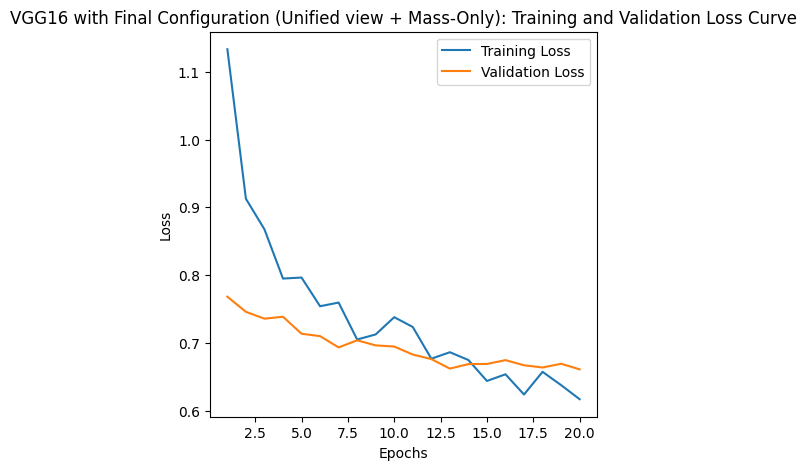

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16.history, 'VGG16', 'Final Configuration (Unified view + Mass-Only)')

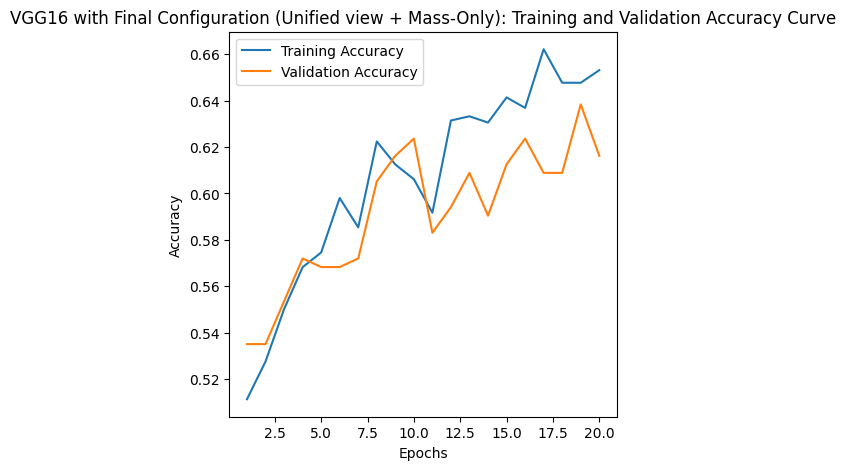

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(vgg16.history, 'VGG16', 'Final Configuration (Unified view + Mass-Only)')

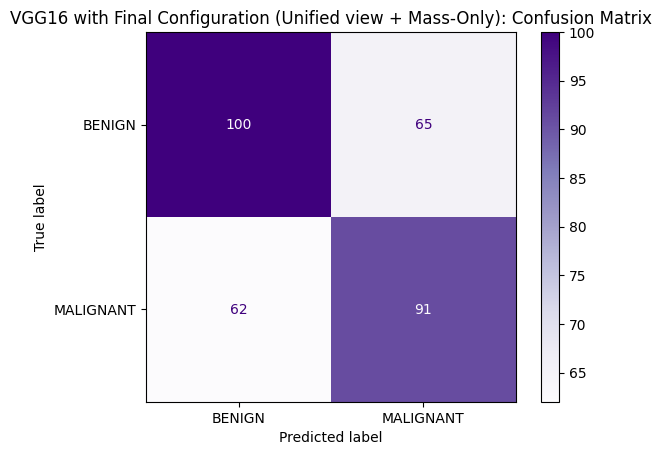

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(test_true_labels, predictions_vgg16, 'VGG16', 'Final Configuration (Unified view + Mass-Only)')

In [ ]:
# Save the trained model
vgg16.save("/content/drive/MyDrive/CM3070_Final_Project_Final_Models/vgg16_final_configuration_unified_mass.keras")

## ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model = select_model('resnet50')
# Print model summary
resnet50_model.summary()
# Compile and train the ResNet50 model with training data
resnet50, train_time_resnet50, peak_memory_resnet50 = train_selected_model(resnet50_model,
                                                                           train_dataset,
                                                                           val_dataset,
                                                                           FINAL_EPOCHS,
                                                                           early_stopping,
                                                                           class_weights_dict)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 35s 569ms/step - accuracy: 0.5438 - auc: 0.5328 - loss: 0.7402 - precision: 0.4965 - recall: 0.2803 - val_accuracy: 0.5646 - val_auc: 0.5895 - val_loss: 0.6792 - val_precision: 0.6562 - val_recall: 0.1641
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 490ms/step - accuracy: 0.5727 - auc: 0.5950 - loss: 0.6903 - precision: 0.5455 - recall: 0.3579 - val_accuracy: 0.5830 - val_auc: 0.6208 - val_loss: 0.6591 - val_precision: 0.8261 - val_recall: 0.1484
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 479ms/step - accuracy: 0.6396 - auc: 0.6724 - loss: 0.6424 - precision: 0.6646 - recall: 0.4175 - val_accuracy: 0.6458 - val_auc: 0.6898 - val_loss: 0.6589 - val_precision: 0.6404 - val_recall: 0.5703
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 477ms/step - accuracy: 0.6549 - auc: 0.6866 - loss: 0.6244 - precision: 0.6806 - recall: 0.4533 - val_accuracy: 0.6568 - val_auc: 0.7014 - val_loss: 0.6339 - val_precision: 0.7612 - val_recall: 0.3984
Epoch 5/20
35/35 ━━━━━━━━━━━

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
logits_resnet50, predictions_resnet50, metrics_dict_resnet50, infer_time_resnet50 = generate_predictions_and_evaluations(resnet50,
                                                                                                                         test_dataset,
                                                                                                                         test_true_labels,
                                                                                                                         PREDICTION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 383ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 236ms/step - accuracy: 0.6415 - auc: 0.6560 - loss: 0.6299 - precision: 0.7294 - recall: 0.4052


In [ ]:
# Temperature for ResNet50 (Initial)
temperature_resnet50 = tf.Variable(1.0, trainable=True, dtype=tf.float32)
# Optimized temperature for ResNet50
optimized_temperature_resnet50 = temperature_scaling(logits_resnet50, test_true_labels_tensor, temperature_resnet50)

In [ ]:
# Compute scaled logits from original logits and optimized temperature
scaled_logits_resnet50 = logits_resnet50 / optimized_temperature_resnet50

# Compute ECE Score
with tf.device("/CPU:0"):
  # ECE Before Temperature Scaling
  ece_before_scaling_resnet50 = tfp.stats.expected_calibration_error(
      10,
      logits_resnet50,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )
  # ECE After Temperature Scaling
  ece_after_scaling_resnet50 = tfp.stats.expected_calibration_error(
      10,
      scaled_logits_resnet50,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )

print(ece_before_scaling_resnet50.numpy())
print(ece_after_scaling_resnet50.numpy())

0.48113197
0.48113197


In [ ]:
# Compute predicted probabilities and calibrated predicted probabilities
pred_probabilities_resnet50 = tf.nn.sigmoid(logits_resnet50)
pred_calib_probabilities_resnet50 = tf.nn.sigmoid(scaled_logits_resnet50)

# Calculate Brier Score
brier_score_before_scaling_resnet50 = compute_brier_score(pred_probabilities_resnet50, test_true_labels_tensor)
brier_score_after_scaling_resnet50 = compute_brier_score(pred_calib_probabilities_resnet50, test_true_labels_tensor)

print(brier_score_before_scaling_resnet50.numpy())
print(brier_score_after_scaling_resnet50.numpy())

0.2218219
0.22048442


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_results_df = generate_final_results_df(
    model_name='ResNet50',
    view='Unified-View',
    lesion='Mass-Only-Lesion',
    eval_metrics=metrics_dict_resnet50,
    train_time=train_time_resnet50,
    infer_time=infer_time_resnet50,
    peak_memory=peak_memory_resnet50,
    ece_before_scaling=ece_before_scaling_resnet50.numpy(),
    ece_after_scaling=ece_after_scaling_resnet50.numpy(),
    brier_score_before_scaling=brier_score_before_scaling_resnet50.numpy(),
    brier_score_after_scaling=brier_score_after_scaling_resnet50.numpy()
)

# Store the results data in results CSV file
store_final_results(results_file_path, resnet50_results_df)

Saved final results


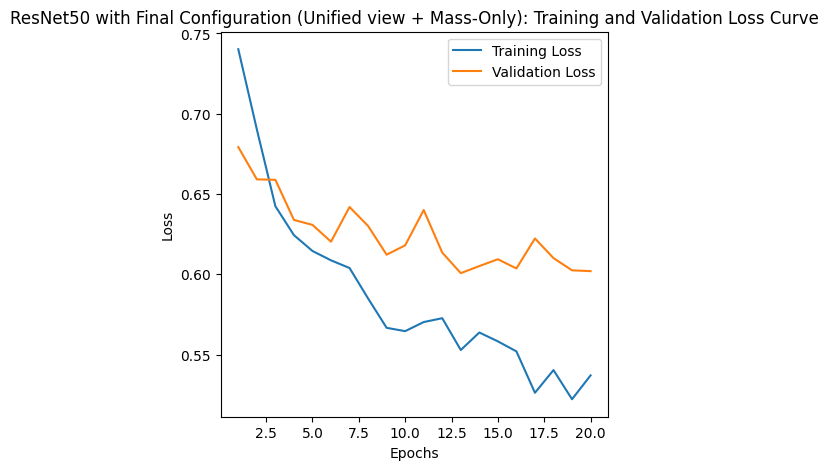

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50.history, 'ResNet50', 'Final Configuration (Unified view + Mass-Only)')

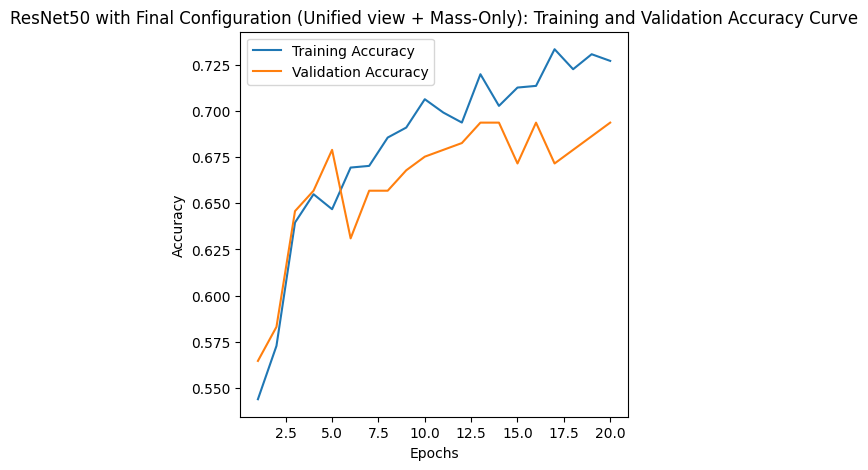

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(resnet50.history, 'ResNet50', 'Final Configuration (Unified view + Mass-Only)')

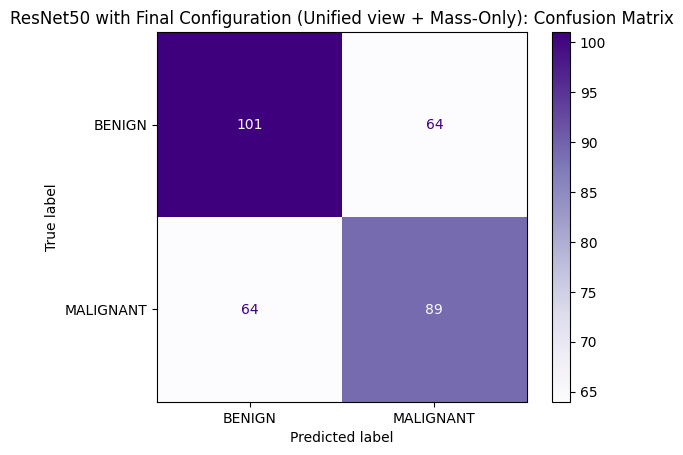

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(test_true_labels, predictions_resnet50, 'ResNet50', 'Final Configuration (Unified view + Mass-Only)')

In [ ]:
# Save the trained model
resnet50.save("/content/drive/MyDrive/CM3070_Final_Project_Final_Models/resnet50_final_configuration_unified_mass.keras")

## DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model = select_model('densenet121')
# Print model summary
densenet121_model.summary()
# Compile and train the DenseNet121 model with training data
densenet121, train_time_densenet121, peak_memory_densenet121 = train_selected_model(densenet121_model,
                                                                                    train_dataset,
                                                                                    val_dataset,
                                                                                    FINAL_EPOCHS,
                                                                                    early_stopping,
                                                                                    class_weights_dict)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 44s 678ms/step - accuracy: 0.5266 - auc: 0.5181 - loss: 1.7442 - precision: 0.4780 - recall: 0.4533 - val_accuracy: 0.6052 - val_auc: 0.6281 - val_loss: 0.7329 - val_precision: 0.6000 - val_recall: 0.4922
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 30s 511ms/step - accuracy: 0.5537 - auc: 0.5449 - loss: 1.3246 - precision: 0.5102 - recall: 0.4493 - val_accuracy: 0.5904 - val_auc: 0.6211 - val_loss: 0.7198 - val_precision: 0.7576 - val_recall: 0.1953
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 494ms/step - accuracy: 0.5483 - auc: 0.5378 - loss: 1.1958 - precision: 0.5037 - recall: 0.4036 - val_accuracy: 0.5867 - val_auc: 0.6133 - val_loss: 0.7068 - val_precision: 0.7353 - val_recall: 0.1953
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 507ms/step - accuracy: 0.5583 - auc: 0.5657 - loss: 1.0715 - precision: 0.5167 - recall: 0.4314 - val_accuracy: 0.6089 - val_auc: 0.6295 - val_loss: 0.6779 - val_precision: 0.6618 - val_recall: 0.3516
Epoch 5/20
35/35 ━━━━━━━━━━━

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
logits_densenet121, predictions_densenet121, metrics_dict_densenet121, infer_time_densenet121 = generate_predictions_and_evaluations(densenet121,
                                                                                                                                     test_dataset,
                                                                                                                                     test_true_labels,
                                                                                                                                     PREDICTION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 738ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - accuracy: 0.5723 - auc: 0.5800 - loss: 0.6920 - precision: 0.6232 - recall: 0.2810


In [ ]:
# Temperature for DenseNet121 (Initial)
temperature_densenet121 = tf.Variable(1.0, trainable=True, dtype=tf.float32)
# Optimized temperature for DenseNet121
optimized_temperature_densenet121 = temperature_scaling(logits_densenet121, test_true_labels_tensor, temperature_densenet121)

In [ ]:
# Compute scaled logits from original logits and optimized temperature
scaled_logits_densenet121 = logits_densenet121 / optimized_temperature_densenet121

# Compute ECE Score
with tf.device("/CPU:0"):
  # ECE Before Temperature Scaling
  ece_before_scaling_densenet121 = tfp.stats.expected_calibration_error(
      10,
      logits_densenet121,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )
  # ECE After Temperature Scaling
  ece_after_scaling_densenet121 = tfp.stats.expected_calibration_error(
      10,
      scaled_logits_densenet121,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )

print(ece_before_scaling_densenet121.numpy())
print(ece_after_scaling_densenet121.numpy())

0.48113197
0.48113197


In [ ]:
# Compute predicted probabilities and calibrated predicted probabilities
pred_probabilities_densenet121 = tf.nn.sigmoid(logits_densenet121)
pred_calib_probabilities_densenet121 = tf.nn.sigmoid(scaled_logits_densenet121)

# Calculate Brier Score
brier_score_before_scaling_densenet121 = compute_brier_score(pred_probabilities_densenet121, test_true_labels_tensor)
brier_score_after_scaling_densenet121 = compute_brier_score(pred_calib_probabilities_densenet121, test_true_labels_tensor)

print(brier_score_before_scaling_densenet121.numpy())
print(brier_score_after_scaling_densenet121.numpy())

0.24684522
0.24033435


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_results_df = generate_final_results_df(
    model_name='DenseNet121',
    view='Unified-View',
    lesion='Mass-Only-Lesion',
    eval_metrics=metrics_dict_densenet121,
    train_time=train_time_densenet121,
    infer_time=infer_time_densenet121,
    peak_memory=peak_memory_densenet121,
    ece_before_scaling=ece_before_scaling_densenet121.numpy(),
    ece_after_scaling=ece_after_scaling_densenet121.numpy(),
    brier_score_before_scaling=brier_score_before_scaling_densenet121.numpy(),
    brier_score_after_scaling=brier_score_after_scaling_densenet121.numpy()
)

# Store the results data in results CSV file
store_final_results(results_file_path, densenet121_results_df)

Saved final results


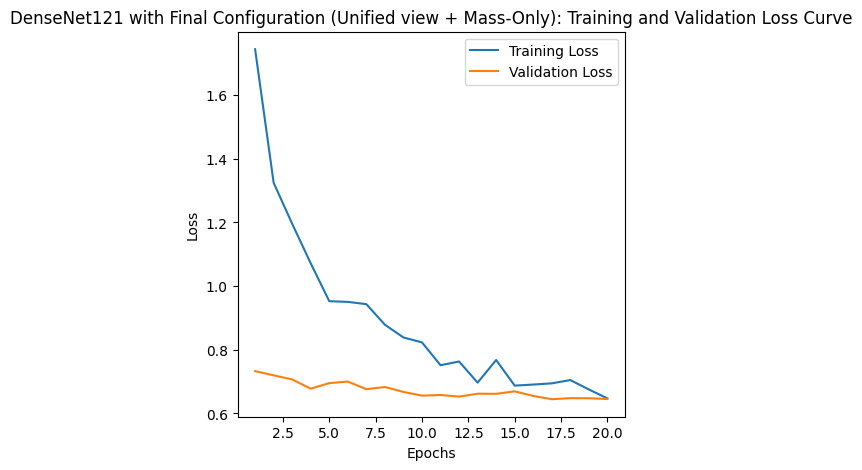

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121.history, 'DenseNet121', 'Final Configuration (Unified view + Mass-Only)')

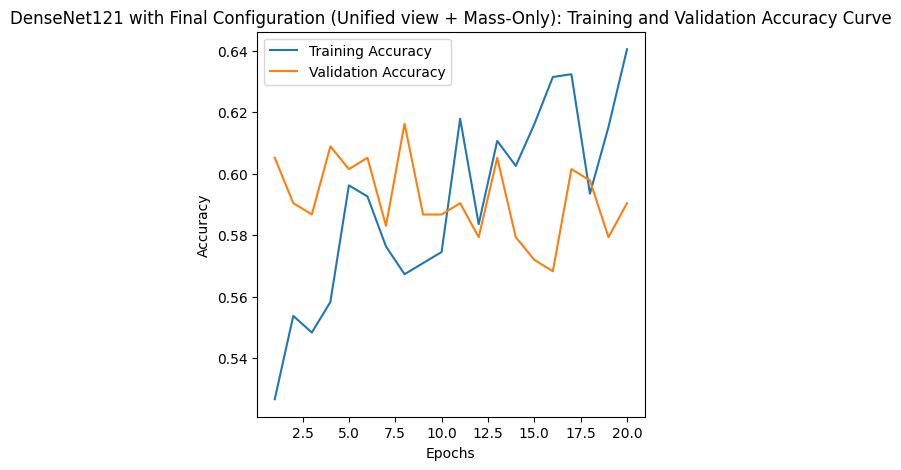

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(densenet121.history, 'DenseNet121', 'Final Configuration (Unified view + Mass-Only)')

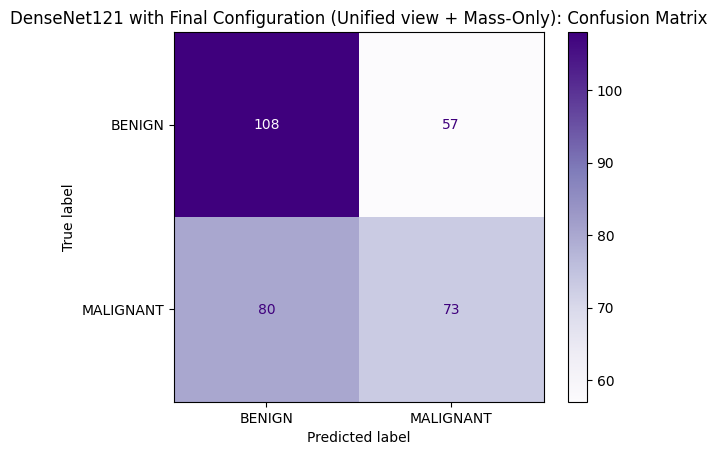

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(test_true_labels, predictions_densenet121, 'DenseNet121', 'Final Configuration (Unified view + Mass-Only)')

In [ ]:
# Save the trained model
densenet121.save("/content/drive/MyDrive/CM3070_Final_Project_Final_Models/densenet121_final_configuration_unified_mass.keras")

## MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model = select_model('mobilenetv2')
# Print model summary
mobilenetv2_model.summary()
# Compile and train the MobileNetV2 model with training data
mobilenetv2, train_time_mobilenetv2, peak_memory_mobilenetv2 = train_selected_model(mobilenetv2_model,
                                                                                    train_dataset,
                                                                                    val_dataset,
                                                                                    FINAL_EPOCHS,
                                                                                    early_stopping,
                                                                                    class_weights_dict)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 30s 479ms/step - accuracy: 0.5465 - auc: 0.5350 - loss: 0.7563 - precision: 0.5015 - recall: 0.3260 - val_accuracy: 0.5683 - val_auc: 0.6075 - val_loss: 0.6906 - val_precision: 0.6038 - val_recall: 0.2500
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 422ms/step - accuracy: 0.5754 - auc: 0.5825 - loss: 0.6893 - precision: 0.5613 - recall: 0.3002 - val_accuracy: 0.5572 - val_auc: 0.6018 - val_loss: 0.6817 - val_precision: 0.6053 - val_recall: 0.1797
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 418ms/step - accuracy: 0.5556 - auc: 0.5604 - loss: 0.7099 - precision: 0.5216 - recall: 0.2644 - val_accuracy: 0.6089 - val_auc: 0.6081 - val_loss: 0.6962 - val_precision: 0.6170 - val_recall: 0.4531
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 423ms/step - accuracy: 0.5863 - auc: 0.6061 - loss: 0.6841 - precision: 0.5812 - recall: 0.3201 - val_accuracy: 0.5867 - val_auc: 0.5923 - val_loss: 0.6902 - val_precision: 0.6143 - val_recall: 0.3359
Epoch 5/20
35/35 ━━━━━━━━━━━

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
logits_mobilenetv2, predictions_mobilenetv2, metrics_dict_mobilenetv2, infer_time_mobilenetv2 = generate_predictions_and_evaluations(mobilenetv2,
                                                                                                                                     test_dataset,
                                                                                                                                     test_true_labels,
                                                                                                                                     PREDICTION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 255ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - accuracy: 0.5566 - auc: 0.5772 - loss: 0.6958 - precision: 0.5732 - recall: 0.3072


In [ ]:
# Temperature for MobileNetV2 (Initial)
temperature_mobilenetv2 = tf.Variable(1.0, trainable=True, dtype=tf.float32)
# Optimized temperature for MobileNetV2
optimized_temperature_mobilenetv2 = temperature_scaling(logits_mobilenetv2, test_true_labels_tensor, temperature_mobilenetv2)

In [ ]:
# Compute scaled logits from original logits and optimized temperature
scaled_logits_mobilenetv2 = logits_mobilenetv2 / optimized_temperature_mobilenetv2

# Compute ECE Score
with tf.device("/CPU:0"):
  # ECE Before Temperature Scaling
  ece_before_scaling_mobilenetv2 = tfp.stats.expected_calibration_error(
      10,
      logits_mobilenetv2,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )
  # ECE After Temperature Scaling
  ece_after_scaling_mobilenetv2 = tfp.stats.expected_calibration_error(
      10,
      scaled_logits_mobilenetv2,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )

print(ece_before_scaling_mobilenetv2.numpy())
print(ece_after_scaling_mobilenetv2.numpy())

0.48113197
0.48113197


In [ ]:
# Compute predicted probabilities and calibrated predicted probabilities
pred_probabilities_mobilenetv2 = tf.nn.sigmoid(logits_mobilenetv2)
pred_calib_probabilities_mobilenetv2 = tf.nn.sigmoid(scaled_logits_mobilenetv2)

# Calculate Brier Score
brier_score_before_scaling_mobilenetv2 = compute_brier_score(pred_probabilities_mobilenetv2, test_true_labels_tensor)
brier_score_after_scaling_mobilenetv2 = compute_brier_score(pred_calib_probabilities_mobilenetv2, test_true_labels_tensor)

print(brier_score_before_scaling_mobilenetv2.numpy())
print(brier_score_after_scaling_mobilenetv2.numpy())

0.25067896
0.24464881


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_results_df = generate_final_results_df(
    model_name='MobileNetV2',
    view='Unified-View',
    lesion='Mass-Only-Lesion',
    eval_metrics=metrics_dict_mobilenetv2,
    train_time=train_time_mobilenetv2,
    infer_time=infer_time_mobilenetv2,
    peak_memory=peak_memory_mobilenetv2,
    ece_before_scaling=ece_before_scaling_mobilenetv2.numpy(),
    ece_after_scaling=ece_after_scaling_mobilenetv2.numpy(),
    brier_score_before_scaling=brier_score_before_scaling_mobilenetv2.numpy(),
    brier_score_after_scaling=brier_score_after_scaling_mobilenetv2.numpy()
)

# Store the results data in results CSV file
store_final_results(results_file_path, mobilenetv2_results_df)

Saved final results


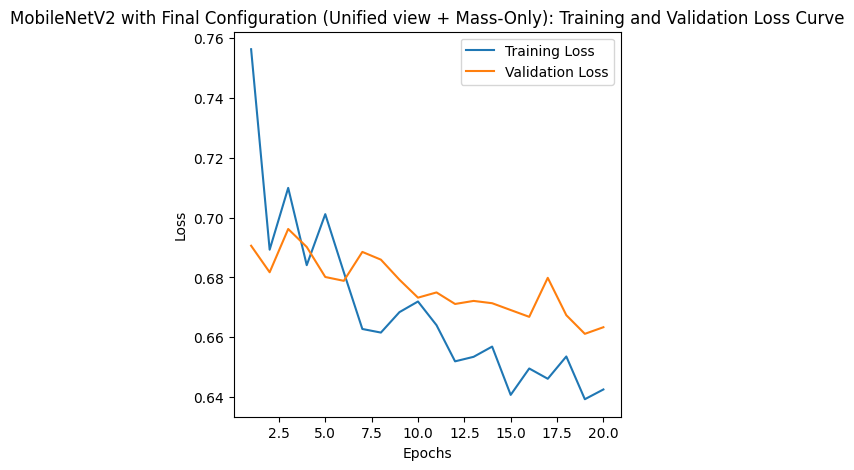

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2.history, 'MobileNetV2', 'Final Configuration (Unified view + Mass-Only)')

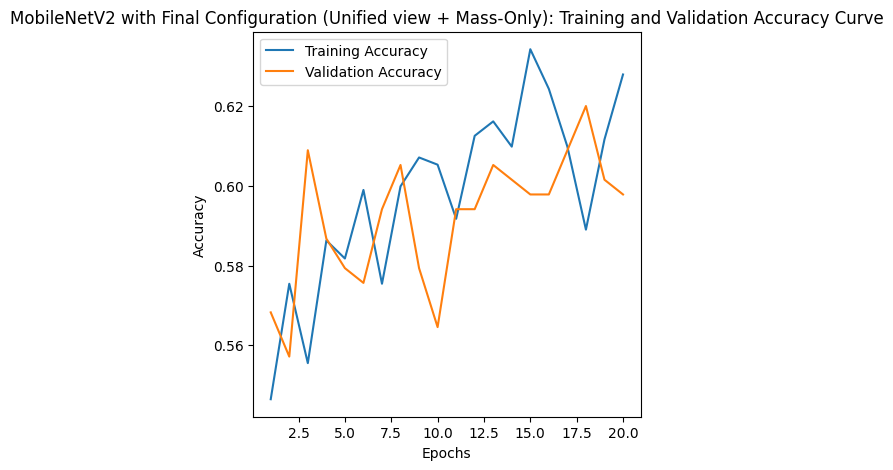

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(mobilenetv2.history, 'MobileNetV2', 'Final Configuration (Unified view + Mass-Only)')

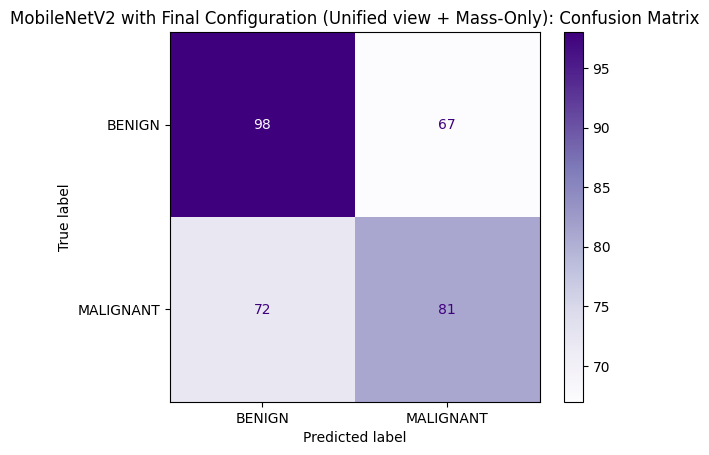

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(test_true_labels, predictions_mobilenetv2, 'MobileNetV2', 'Final Configuration (Unified view + Mass-Only)')

In [ ]:
# Save the trained model
mobilenetv2.save("/content/drive/MyDrive/CM3070_Final_Project_Final_Models/mobilenetv2_final_configuration_unified_mass.keras")

## EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model = select_model('efficientnetb0')
# Print model summary
efficientnetb0_model.summary()
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0, train_time_efficientnetb0, peak_memory_efficientnetb0 = train_selected_model(efficientnetb0_model,
                                                                                             train_dataset,
                                                                                             val_dataset,
                                                                                             FINAL_EPOCHS,
                                                                                             early_stopping,
                                                                                             class_weights_dict)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense256 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 36s 544ms/step - accuracy: 0.5556 - auc: 0.5680 - loss: 0.6831 - precision: 0.5545 - recall: 0.1113 - val_accuracy: 0.5941 - val_auc: 0.6181 - val_loss: 0.6791 - val_precision: 0.6154 - val_recall: 0.3750
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 440ms/step - accuracy: 0.6287 - auc: 0.6516 - loss: 0.6519 - precision: 0.6554 - recall: 0.3857 - val_accuracy: 0.5867 - val_auc: 0.6191 - val_loss: 0.6577 - val_precision: 0.7353 - val_recall: 0.1953
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 473ms/step - accuracy: 0.6296 - auc: 0.6729 - loss: 0.6342 - precision: 0.7123 - recall: 0.3101 - val_accuracy: 0.6199 - val_auc: 0.6487 - val_loss: 0.6572 - val_precision: 0.6582 - val_recall: 0.4062
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 432ms/step - accuracy: 0.6621 - auc: 0.7036 - loss: 0.6162 - precision: 0.7398 - recall: 0.3956 - val_accuracy: 0.6310 - val_auc: 0.6664 - val_loss: 0.6513 - val_precision: 0.6750 - val_recall: 0.4219
Epoch 5/20
35/35 ━━━━━━━━━━━

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
logits_efficientnetb0, predictions_efficientnetb0, metrics_dict_efficientnetb0, infer_time_efficientnetb0 = generate_predictions_and_evaluations(efficientnetb0,
                                                                                                                                                 test_dataset,
                                                                                                                                                 test_true_labels,
                                                                                                                                                 PREDICTION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 378ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - accuracy: 0.6384 - auc: 0.7038 - loss: 0.6150 - precision: 0.7879 - recall: 0.3399


In [ ]:
# Temperature for EfficientNet-B0 (Initial)
temperature_efficientnetb0 = tf.Variable(1.0, trainable=True, dtype=tf.float32)
# Optimized temperature for EfficientNet-B0
optimized_temperature_efficientnetb0 = temperature_scaling(logits_efficientnetb0, test_true_labels_tensor, temperature_efficientnetb0)

In [ ]:
# Compute scaled logits from original logits and optimized temperature
scaled_logits_efficientnetb0 = logits_efficientnetb0 / optimized_temperature_efficientnetb0

# Compute ECE Score
with tf.device("/CPU:0"):
  # ECE Before Temperature Scaling
  ece_before_scaling_efficientnetb0 = tfp.stats.expected_calibration_error(
      10,
      logits_efficientnetb0,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )
  # ECE After Temperature Scaling
  ece_after_scaling_efficientnetb0 = tfp.stats.expected_calibration_error(
      10,
      scaled_logits_efficientnetb0,
      tf.cast(test_true_labels_tensor_squeezed, tf.int32)
  )

print(ece_before_scaling_efficientnetb0.numpy())
print(ece_after_scaling_efficientnetb0.numpy())

0.48113197
0.48113197


In [ ]:
# Compute predicted probabilities and calibrated predicted probabilities
pred_probabilities_efficientnetb0 = tf.nn.sigmoid(logits_efficientnetb0)
pred_calib_probabilities_efficientnetb0 = tf.nn.sigmoid(scaled_logits_efficientnetb0)

# Calculate Brier Score
brier_score_before_scaling_efficientnetb0 = compute_brier_score(pred_probabilities_efficientnetb0, test_true_labels_tensor)
brier_score_after_scaling_efficientnetb0 = compute_brier_score(pred_calib_probabilities_efficientnetb0, test_true_labels_tensor)

print(brier_score_before_scaling_efficientnetb0.numpy())
print(brier_score_after_scaling_efficientnetb0.numpy())

0.2122947
0.21232653


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_results_df = generate_final_results_df(
    model_name='EfficientNet-B0',
    view='Unified-View',
    lesion='Mass-Only-Lesion',
    eval_metrics=metrics_dict_efficientnetb0,
    train_time=train_time_efficientnetb0,
    infer_time=infer_time_efficientnetb0,
    peak_memory=peak_memory_efficientnetb0,
    ece_before_scaling=ece_before_scaling_efficientnetb0.numpy(),
    ece_after_scaling=ece_after_scaling_efficientnetb0.numpy(),
    brier_score_before_scaling=brier_score_before_scaling_efficientnetb0.numpy(),
    brier_score_after_scaling=brier_score_after_scaling_efficientnetb0.numpy()
)

# Store the results data in results CSV file
store_final_results(results_file_path, efficientnetb0_results_df)

Saved final results


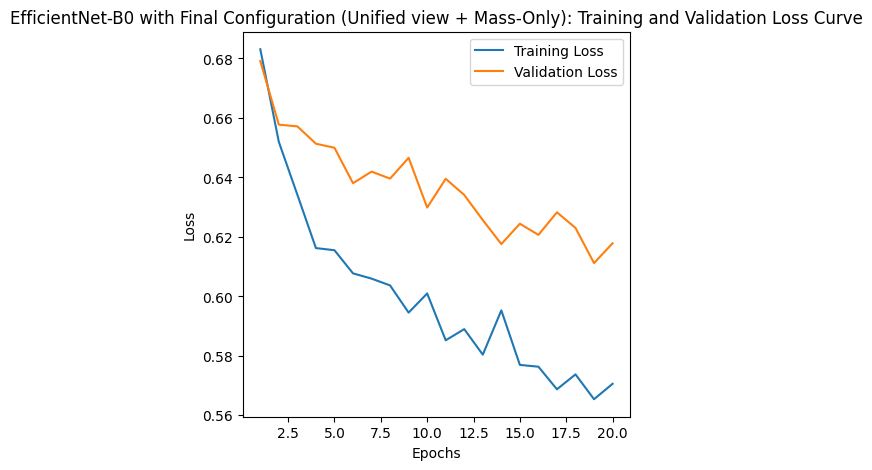

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0.history, 'EfficientNet-B0', 'Final Configuration (Unified view + Mass-Only)')

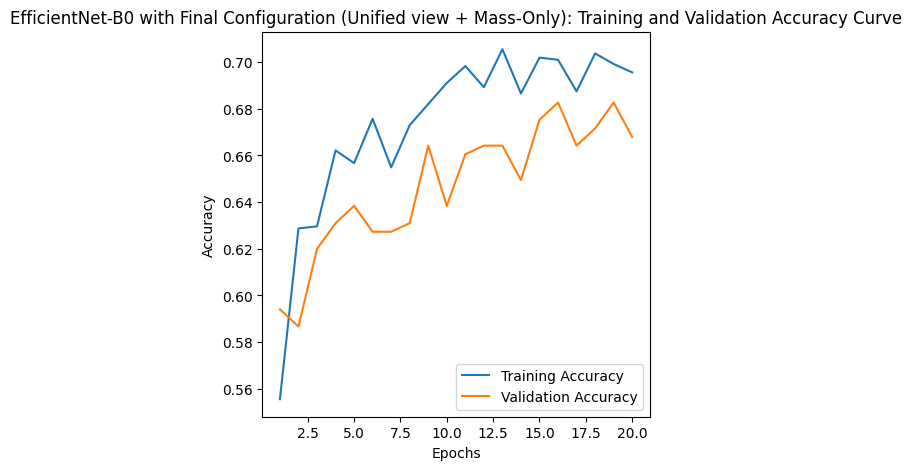

In [ ]:
# Plot training-validation accuracy curve
plot_training_validation_accuracy(efficientnetb0.history, 'EfficientNet-B0', 'Final Configuration (Unified view + Mass-Only)')

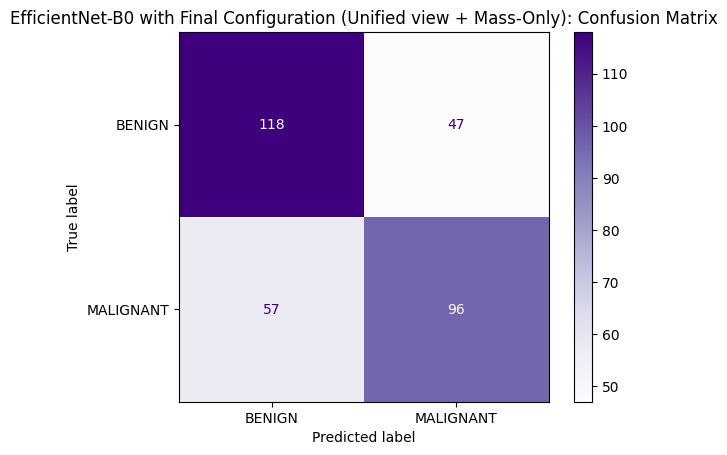

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(test_true_labels, predictions_efficientnetb0, 'EfficientNet-B0', 'Final Configuration (Unified view + Mass-Only)')

In [ ]:
# Save the trained model
efficientnetb0.save("/content/drive/MyDrive/CM3070_Final_Project_Final_Models/efficientnetb0_final_configuration_unified_mass.keras")